# 04 — Training

In [8]:
import os
if not os.path.exists('MiniGPT'):
    !git clone https://github.com/userKk1/MiniGPT.git
%cd MiniGPT

Cloning into 'MiniGPT'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 87 (delta 37), reused 45 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 131.46 KiB | 841.00 KiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/MiniGPT


In [9]:
import sys, json, math, time
sys.path.append('.')

import numpy as np
import torch
import matplotlib.pyplot as plt

from config import cfg, DATA_PROCESSED_DIR, CHECKPOINTS_DIR, LOGS_DIR, FIGURES_DIR
from src.model import GPT

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu':
    print('WARNING: no GPU detected -- go to Runtime > Change runtime type > GPU')
print('device:', device)

device: cuda


## 1. Load tokenized data and vocab

`train.bin`/`val.bin` are raw uint16 arrays on disk. We memory-map them
instead of loading into RAM, irrelevant at this corpus size, but it's the
right habit for when we scale the corpus up later.

In [10]:
!python -m src.data

Resolving data files: 100% 54/54 [00:00<00:00, 11301.45it/s]
Collected 4138 files, 20.00 MB
Wrote /content/MiniGPT/data/raw/corpus_raw.txt (21.0 MB)


In [11]:
!python -m src.tokenizer

Corpus length: 20,964,485 characters
Vocab size: 99
train: 18,868,036 tokens
val:   2,096,449 tokens
Saved to /content/MiniGPT/data/processed


In [12]:
vocab = json.loads((DATA_PROCESSED_DIR / 'vocab.json').read_text())
vocab_size = vocab['vocab_size']
itos = {int(k): v for k, v in vocab['itos'].items()}
print('vocab_size:', vocab_size)

train_data = np.memmap(DATA_PROCESSED_DIR / 'train.bin', dtype=np.uint16, mode='r')
val_data = np.memmap(DATA_PROCESSED_DIR / 'val.bin', dtype=np.uint16, mode='r')
print(f'train tokens: {len(train_data):,}  val tokens: {len(val_data):,}')

vocab_size: 99
train tokens: 18,868,036  val tokens: 2,096,449


## 2. Batching

Sample random starting positions, pull a `block_size`-length window as input
and the same window shifted by one as the target (next-token prediction).

In [13]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    block_size = cfg.model.block_size
    batch_size = cfg.train.batch_size
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

# sanity check
xb, yb = get_batch('train')
print('x:', xb.shape, 'y:', yb.shape)

x: torch.Size([32, 256]) y: torch.Size([32, 256])


## 3. Instantiate the model

In [14]:
model = GPT(vocab_size).to(device)
print(f'Parameters: {model.num_params():,}')

Parameters: 4,850,688


## 4. Optimizer and LR schedule

Linear warmup then cosine decay down to `min_lr` - standard for transformer
training, helps avoid instability in the first few hundred steps when
gradients are largest.

In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.train.learning_rate,
    weight_decay=cfg.train.weight_decay,
)

def get_lr(step):
    t = cfg.train
    if step < t.warmup_steps:
        return t.learning_rate * (step + 1) / t.warmup_steps
    if step > t.lr_decay_steps:
        return t.min_lr
    decay_ratio = (step - t.warmup_steps) / (t.lr_decay_steps - t.warmup_steps)
    coeff = 0.5 * (1 + math.cos(math.pi * decay_ratio))
    return t.min_lr + coeff * (t.learning_rate - t.min_lr)

## 5. Loss estimation

A single batch's loss is noisy. Averaging over `eval_iters` batches gives a
stable number to actually compare across checkpoints.

In [16]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(cfg.train.eval_iters)
        for k in range(cfg.train.eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

## 6. Training loop

Logs train/val loss every `eval_interval` steps and checkpoints every
`checkpoint_every` steps. If Colab disconnects mid-run, rerun this cell after
loading the last checkpoint (see the commented resume line) instead of
starting over.

In [17]:
# To resume from a checkpoint instead of starting fresh, uncomment:
# ckpt = torch.load(CHECKPOINTS_DIR / 'ckpt.pt', map_location=device)
# model.load_state_dict(ckpt['model'])
# optimizer.load_state_dict(ckpt['optimizer'])
# start_step = ckpt['step']
start_step = 0

history = {'step': [], 'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
t0 = time.time()

for step in range(start_step, cfg.train.max_steps):
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    xb, yb = get_batch('train')
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.train.grad_clip)
    optimizer.step()

    if step % cfg.train.eval_interval == 0 or step == cfg.train.max_steps - 1:
        losses = estimate_loss()
        elapsed = time.time() - t0
        print(f"step {step:5d} | train {losses['train']:.4f} | val {losses['val']:.4f} | lr {lr:.2e} | {elapsed:.0f}s")
        history['step'].append(step)
        history['train_loss'].append(losses['train'])
        history['val_loss'].append(losses['val'])

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save({
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'step': step,
                'val_loss': losses['val'],
            }, CHECKPOINTS_DIR / 'ckpt_best.pt')

    if step % cfg.train.checkpoint_every == 0 and step > 0:
        torch.save({
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'step': step,
        }, CHECKPOINTS_DIR / 'ckpt.pt')

print('Training done.')

step     0 | train 4.5829 | val 4.5849 | lr 1.50e-06 | 8s
step   250 | train 2.5459 | val 2.5238 | lr 3.00e-04 | 47s
step   500 | train 2.1964 | val 2.2011 | lr 2.97e-04 | 89s
step   750 | train 1.9242 | val 1.9415 | lr 2.91e-04 | 134s
step  1000 | train 1.6986 | val 1.6850 | lr 2.82e-04 | 183s
step  1250 | train 1.4934 | val 1.4963 | lr 2.69e-04 | 230s
step  1500 | train 1.3626 | val 1.3690 | lr 2.54e-04 | 278s
step  1750 | train 1.2947 | val 1.2974 | lr 2.36e-04 | 326s
step  2000 | train 1.2417 | val 1.2448 | lr 2.17e-04 | 374s
step  2250 | train 1.1875 | val 1.1929 | lr 1.96e-04 | 422s
step  2500 | train 1.1595 | val 1.1634 | lr 1.74e-04 | 470s
step  2750 | train 1.1251 | val 1.1447 | lr 1.52e-04 | 518s
step  3000 | train 1.1017 | val 1.1275 | lr 1.30e-04 | 566s
step  3250 | train 1.0789 | val 1.0963 | lr 1.09e-04 | 614s
step  3500 | train 1.0610 | val 1.0867 | lr 9.00e-05 | 662s
step  3750 | train 1.0426 | val 1.0660 | lr 7.27e-05 | 710s
step  4000 | train 1.0435 | val 1.0698 | lr 

## 7. Save loss log and plot the curve

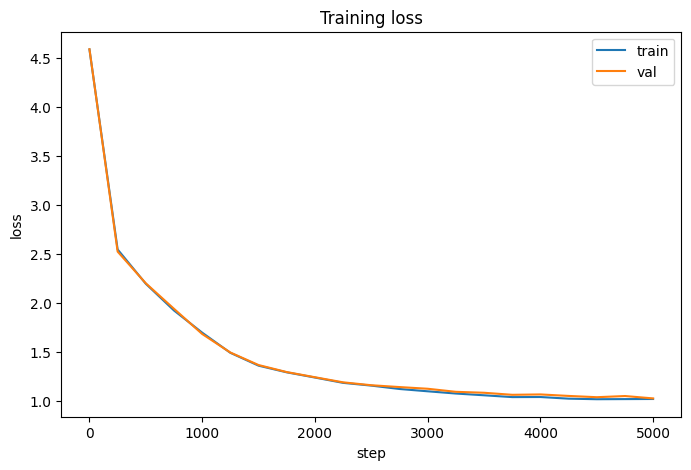

In [18]:
with open(LOGS_DIR / 'loss_log.json', 'w') as f:
    json.dump(history, f, indent=2)

plt.figure(figsize=(8, 5))
plt.plot(history['step'], history['train_loss'], label='train')
plt.plot(history['step'], history['val_loss'], label='val')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training loss')
plt.legend()
plt.savefig(FIGURES_DIR / 'loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Quick generation sanity check

Not a real evaluation -- just confirms the model produces *something*
code-shaped rather than garbage.

In [19]:
def decode(ids):
    return ''.join(itos[i] for i in ids)

context = torch.zeros((1, 1), dtype=torch.long, device=device)  # start from a single pad/first token
generated = model.generate(context, max_new_tokens=300, temperature=0.8, top_k=40)
print(decode(generated[0].tolist()))

			print "Message://two.two.getc/message.org/locations/messages/cache.conference/read/attache.org/locations/message/%s/%s/%s/%s/two.two/enddown.add_locations/message_extend(origin_message_update)) %s\n" % (print, print, print)))


    # and document the orgations extend code that the orgation message
